# CIA 1
## Part B

### Question 1

Installing dependencies and importing libraries

In [1]:
!pip3 install pandas numpy scikit-learn openpyxl --break-system-packages


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_excel("data/QP_Data_road_accident_dataset_with_missing.xlsx")
data.head()

,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Visibility Level,Number of Vehicles Involved,...,Number of Fatalities,Emergency Response Time,Traffic Volume,Road Condition,Accident Cause,Insurance Claims,Medical Cost,Economic Loss,Region,Population Density
0,USA,2002,October,Tuesday,Evening,Rural,Street,Windy,NaN,1,...,2,58.625720,7412.752760,Wet,Weather,4,40499.856980,22072.878500,Europe,3866.273014
1,UK,2014,December,Saturday,Evening,Urban,Street,Windy,168.311358,3,...,1,58.041380,4458.628820,Snow-covered,Mechanical Failure,3,6486.600073,9534.399441,North America,2333.916224
2,USA,2012,July,Sunday,Afternoon,Urban,Highway,Snowy,341.286506,4,...,4,NaN,9856.915064,Wet,Speeding,4,29164.412980,58009.145120,South America,4408.889129
3,UK,2017,May,Saturday,Evening,Urban,Main Road,Clear,489.384536,2,...,3,48.554014,4958.646267,Icy,Distracted Driving,3,25797.212570,20907.151300,Australia,2810.822423
4,Canada,2002,July,Tuesday,Afternoon,Rural,Highway,Rainy,348.344850,1,...,4,18.318250,3843.191463,Icy,Distracted Driving,8,15605.293920,13584.060760,South America,3883.645634


In [4]:
numeric = data.select_dtypes(include=np.number).keys()
print("Numeric data columns: ", numeric)
categorical = data.select_dtypes(include="object").keys()
print("Categorical data columns: ", categorical)

Numeric data columns:  Index(['Year', 'Visibility Level', 'Number of Vehicles Involved',
       'Speed Limit', 'Driver Alcohol Level', 'Driver Fatigue',
       'Pedestrians Involved', 'Cyclists Involved', 'Number of Injuries',
       'Number of Fatalities', 'Emergency Response Time', 'Traffic Volume',
       'Insurance Claims', 'Medical Cost', 'Economic Loss',
       'Population Density'],
      dtype='object')
Categorical data columns:  Index(['Country', 'Month', 'Day of Week', 'Time of Day', 'Urban/Rural',
       'Road Type', 'Weather Conditions', 'Driver Age Group', 'Driver Gender',
       'Vehicle Condition', 'Accident Severity', 'Road Condition',
       'Accident Cause', 'Region'],
      dtype='object')


In [5]:
print("Data types of all columns: ", data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      132000 non-null  object 
 1   Year                         132000 non-null  int64  
 2   Month                        132000 non-null  object 
 3   Day of Week                  132000 non-null  object 
 4   Time of Day                  132000 non-null  object 
 5   Urban/Rural                  132000 non-null  object 
 6   Road Type                    132000 non-null  object 
 7   Weather Conditions           132000 non-null  object 
 8   Visibility Level             125400 non-null  float64
 9   Number of Vehicles Involved  132000 non-null  int64  
 10  Speed Limit                  132000 non-null  int64  
 11  Driver Age Group             132000 non-null  object 
 12  Driver Gender                132000 non-null  object 
 13 

All the required information has been printed.

All the columns have appropriate data types.

### Question 2a
Descriptive statistics for all the columns

In [6]:
data.describe()

,Year,Visibility Level,Number of Vehicles Involved,Speed Limit,Driver Alcohol Level,Driver Fatigue,Pedestrians Involved,Cyclists Involved,Number of Injuries,Number of Fatalities,Emergency Response Time,Traffic Volume,Insurance Claims,Medical Cost,Economic Loss,Population Density
count,132000.000000,125400.000000,132000.000000,132000.000000,104893.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,118824.000000,125400.000000,132000.000000,106979.000000,118800.000000,125400.000000
mean,2011.973348,275.104755,2.501227,74.544068,0.110463,0.500576,1.000773,0.998356,9.508205,1.995439,32.486666,5039.695672,4.495621,22999.326535,46028.388017,2505.985119
std,7.198624,129.946180,1.117272,26.001448,0.066818,0.500002,0.816304,0.817764,5.774366,1.412974,15.900793,2861.300571,2.867347,13309.840366,26642.146034,1441.036753
min,2000.000000,50.001928,1.000000,30.000000,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,5.000177,100.062626,0.000000,500.110091,1000.335085,10.002669
25%,2006.000000,162.422604,2.000000,52.000000,0.053893,0.000000,0.000000,0.000000,5.000000,1.000000,18.694200,2554.836546,2.000000,11594.699610,23253.528405,1257.505421
50%,2012.000000,274.808977,3.000000,74.000000,0.107667,1.000000,1.000000,1.000000,9.000000,2.000000,32.549514,5033.213155,4.000000,22687.634120,45484.381415,2504.196516
75%,2018.000000,388.070736,3.000000,97.000000,0.161436,1.000000,2.000000,2.000000,15.000000,3.000000,46.288919,7523.931508,7.000000,33869.677745,67731.981662,3757.099191
max,2024.000000,499.999646,4.000000,119.000000,0.249989,1.000000,2.000000,2.000000,19.000000,4.000000,59.999588,9999.997468,9.000000,49999.930130,99999.622970,4999.991745


The 'Economic Loss' column shows the highest variance from the mean with a value of 26642.146034 for it's standard deviation.

### Question 2b

In [7]:
print("Medical Cost:")
print("Mean: ", data['Medical Cost'].mean())
print("Median: ", data['Medical Cost'].median())

Medical Cost:
Mean:  22999.326534801297
Median:  22687.63412


The median is lesser than the mean. Hence the distribution of 'Medical Cost' is skewed to the right or positively skewed.

### Question 3a

In [8]:
data.isnull().sum()

Country                            0
Year                               0
Month                              0
Day of Week                        0
Time of Day                        0
Urban/Rural                        0
Road Type                          0
Weather Conditions                 0
Visibility Level                6600
Number of Vehicles Involved        0
Speed Limit                        0
Driver Age Group                   0
Driver Gender                      0
Driver Alcohol Level           27107
Driver Fatigue                     0
Vehicle Condition                  0
Pedestrians Involved               0
Cyclists Involved                  0
Accident Severity                  0
Number of Injuries                 0
Number of Fatalities               0
Emergency Response Time        13176
Traffic Volume                  6600
Road Condition                     0
Accident Cause                     0
Insurance Claims                   0
Medical Cost                   25021
E

In [9]:
print("Percentage of missing values: ")
data.isnull().sum() / data.shape[0] * 100.00

Percentage of missing values: 


Country                         0.000000
Year                            0.000000
Month                           0.000000
Day of Week                     0.000000
Time of Day                     0.000000
Urban/Rural                     0.000000
Road Type                       0.000000
Weather Conditions              0.000000
Visibility Level                5.000000
Number of Vehicles Involved     0.000000
Speed Limit                     0.000000
Driver Age Group                0.000000
Driver Gender                   0.000000
Driver Alcohol Level           20.535606
Driver Fatigue                  0.000000
Vehicle Condition               0.000000
Pedestrians Involved            0.000000
Cyclists Involved               0.000000
Accident Severity               0.000000
Number of Injuries              0.000000
Number of Fatalities            0.000000
Emergency Response Time         9.981818
Traffic Volume                  5.000000
Road Condition                  0.000000
Accident Cause  

### Question 3b
Since 'Visibility Level', 'Population Density' and 'Traffic Volume' have 5 percent missing values, we can use mode imputation.

### Question 3c
- Emergency Response Time (9.98%): Falls in the 5-10% range. We will use mean/median/mode substitution.
- Driver Alcohol Level (20.5%) & Medical Cost (18.9%): Have >10% missing values. We will use random sample imputation.

### Question 3d
Missingness in 'Driver Alcohol Level' can be:
- MAR (Missing At Random): If the missingness depends on other observed variables like 'Time of Day' or 'Accident Severity'.
- MNAR (Missing Not At Random): If it depends on the alcohol level itself, like, highly intoxicated drivers refusing the test to avoid legal consequences.

### Question 4a

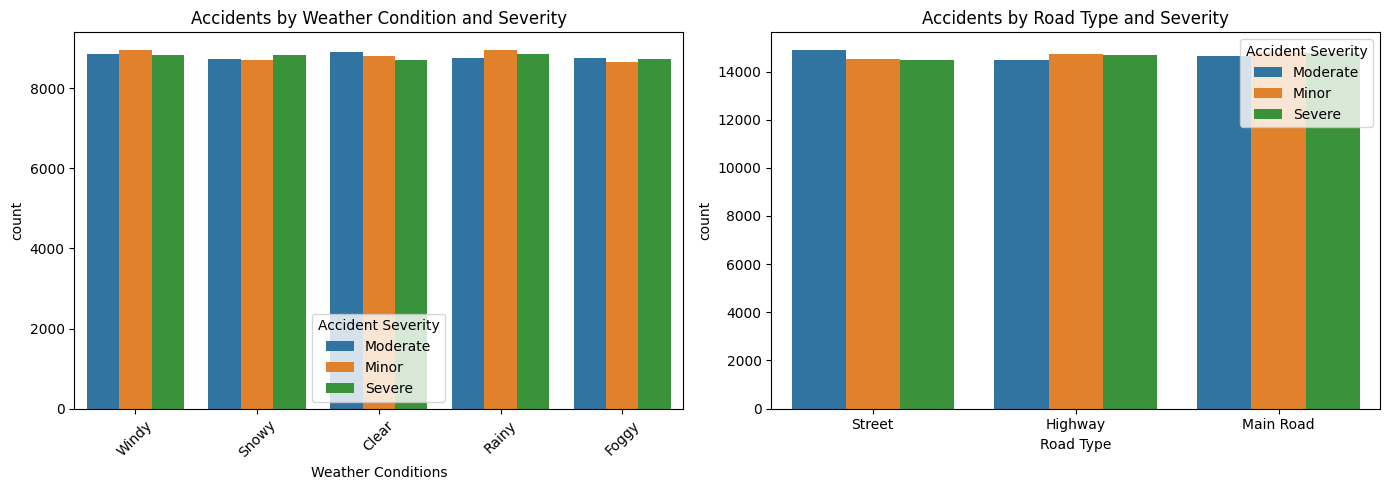

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=data, x='Weather Conditions', hue='Accident Severity', ax=axes[0])
axes[0].set_title('Accidents by Weather Condition and Severity')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=data, x='Road Type', hue='Accident Severity', ax=axes[1])
axes[1].set_title('Accidents by Road Type and Severity')
plt.tight_layout()
plt.show()


### Question 4b

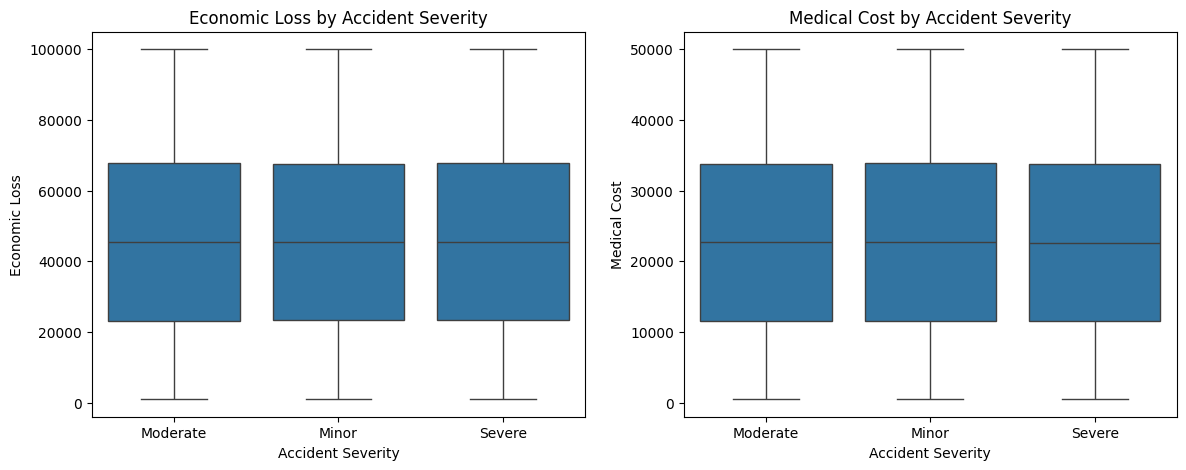

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=data, x='Accident Severity', y='Economic Loss', ax=axes[0])
axes[0].set_title('Economic Loss by Accident Severity')

sns.boxplot(data=data, x='Accident Severity', y='Medical Cost', ax=axes[1])
axes[1].set_title('Medical Cost by Accident Severity')
plt.show()

### Question 4c

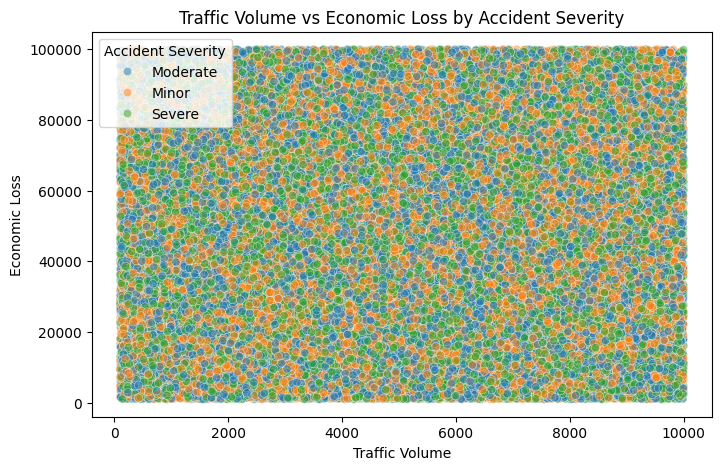

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='Traffic Volume', y='Economic Loss', hue='Accident Severity', alpha=0.5)
plt.title('Traffic Volume vs Economic Loss by Accident Severity')
plt.show()

### Question 4d
Intrpretations:
1. Weather and Severity: Severe accidents are more seen in foggy/snowy weather. Minor accidents can be seen as the major contributor.
2. Economic Loss by Severity: The boxplots show that Economic Loss and Medical Cost do not vary much across accident severities.
3. Traffic Volume vs Economic Loss: There is no clear linear relationship between traffic volume and economic loss.

### Question 5

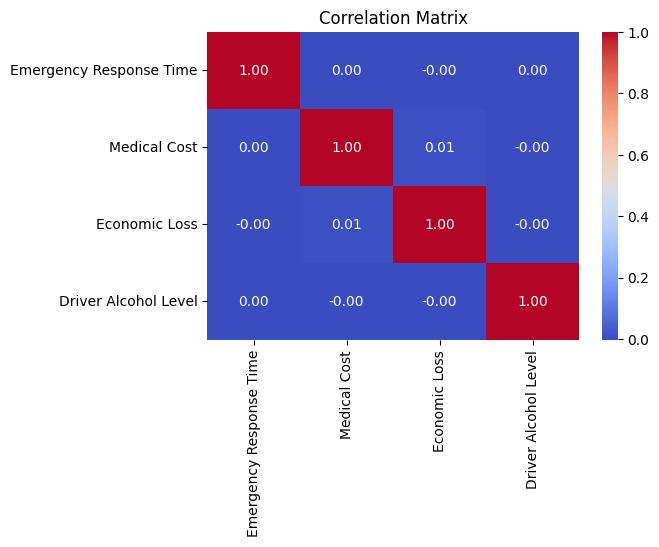

In [13]:
numeric_vars = ['Emergency Response Time', 'Medical Cost', 'Economic Loss', 'Driver Alcohol Level']
corr_matrix = data[numeric_vars].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


Interpretation:
The correlation matrix shows very weak or near-zero correlations among these variables, meaning they do not strongly linearly depend on each other.

Why categorical variables shouldn't be directly included:
Categorical variables lack an inherent numerical order or magnitude. Mathematical operations used to calculate correlation (like variance and covariance) cannot be meaningfully applied to raw text labels without appropriate encoding.

### Question 6a

In [14]:
cols_to_check = ['Medical Cost', 'Economic Loss', 'Traffic Volume', 'Emergency Response Time']

for col in cols_to_check:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col} has {len(outliers)} outliers.")

Medical Cost has 0 outliers.
Economic Loss has 0 outliers.
Traffic Volume has 0 outliers.
Emergency Response Time has 0 outliers.


### Question 6b
Examination of Medical Cost Outliers:
The maximum value for Medical Cost is approximately 50,000, which can be due to extreme accident cases with fatal injuries. Therefore, these are likely meaningful extreme cases rather than data entry errors.

### Question 7

a. Accident trends over time:
Trends typically show fluctuations across years and may peak during certain months (e.g., winter months due to poor weather or holiday seasons with more travel).

b. Environmental and road conditions:
Poor weather (snow/rain) and wet/icy roads increase the likelihood of accidents by reducing visibility and tire traction, acting as significant contributing factors.

c. Factors influencing severity and impact:
Accident severity is often most significantly influenced by 'Speed Limit', 'Driver Alcohol Level', and 'Number of Vehicles Involved', which directly translate to higher physical impact and subsequent medical/economic costs.

d. Geographic variation:
Accident frequencies and impacts vary across regions due to differing population densities, infrastructure quality, and local traffic laws.